In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from itertools import combinations


In [39]:
df = pd.read_csv("genfeld_rock_properties.csv")

In [40]:
df.columns

Index(['Task', 'Rock_Properties', 'Vp_m_s', 'Vs_m_s', 'Density_g_cc'], dtype='str')

In [41]:
df

,Task,Rock_Properties,Vp_m_s,Vs_m_s,Density_g_cc
0,Task-1,Shale caprock,3300,1700,2.35
1,Task-1,Gas-filled sandstone,4200,2700,2.35
2,Task-1,Brine-filled sandstone,4200,2100,2.45
3,Task-2,Shale caprock,2896,1402,2.25
4,Task-2,Gas-filled sandstone,3322,2215,2.00
5,Task-2,Brine-filled sandstone,3322,1401,2.25
6,Task-3,Shale caprock,2307,1108,2.15
7,Task-3,Gas-filled sandstone,1951,1301,1.95
8,Task-3,Brine-filled sandstone,1951,930,2.20


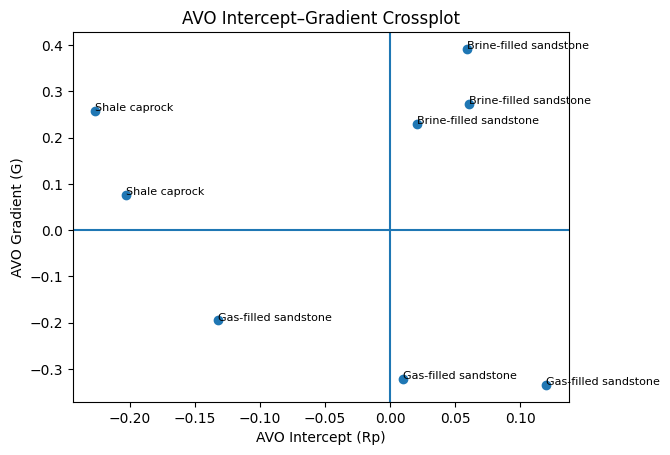

In [25]:
# make sure sorted in the order you want reflections calculated
df = df.copy()

# contrasts between layers
df["dVp"] = df["Vp_m_s"].diff()
df["dVs"] = df["Vs_m_s"].diff()
df["dRho"] = df["Density_g_cc"].diff()

# averages across interface
df["Vp_avg"] = (df["Vp_m_s"] + df["Vp_m_s"].shift()) / 2
df["Vs_avg"] = (df["Vs_m_s"] + df["Vs_m_s"].shift()) / 2
df["Rho_avg"] = (df["Density_g_cc"] + df["Density_g_cc"].shift()) / 2

# fractional contrasts
df["dVp_over_Vp"] = df["dVp"] / df["Vp_avg"]
df["dVs_over_Vs"] = df["dVs"] / df["Vs_avg"]
df["dRho_over_Rho"] = df["dRho"] / df["Rho_avg"]

# AVO intercept and gradient
df["Rp"] = 0.5 * (df["dVp_over_Vp"] + df["dRho_over_Rho"])
df["Rs"] = 0.5 * (df["dVs_over_Vs"] + df["dRho_over_Rho"])
df["G"] = df["Rp"] - 2 * df["Rs"]

df[["Task","Rock_Properties","Rp","Rs","G"]]
# remove first NaN interface
plot_df = df.dropna(subset=["Rp", "G"])

theta = np.radians(np.linspace(0,40,41))  # angles in degrees

df["R_theta"] = df.apply(
    lambda r: r["Rp"] + r["G"] * np.sin(theta)**2 if pd.notna(r["Rp"]) else None,
    axis=1
)

plt.figure()

plt.scatter(plot_df["Rp"], plot_df["G"])

# optional labels
for i, row in plot_df.iterrows():
    plt.text(row["Rp"], row["G"], str(row["Rock_Properties"]), fontsize=8)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("AVO Intercept (Rp)")
plt.ylabel("AVO Gradient (G)")
plt.title("AVO Intercept–Gradient Crossplot")

plt.show()

     Task                   Interface        Rp         G
0  Task-1         Shale -> Gas-filled  0.120000 -0.334545
1  Task-1  Gas-filled -> Brine-filled  0.020833  0.229167
2  Task-2         Shale -> Gas-filled  0.009687 -0.322210
3  Task-2  Gas-filled -> Brine-filled  0.058824  0.391398
4  Task-3         Shale -> Gas-filled -0.132388 -0.195059
5  Task-3  Gas-filled -> Brine-filled  0.060241  0.272345


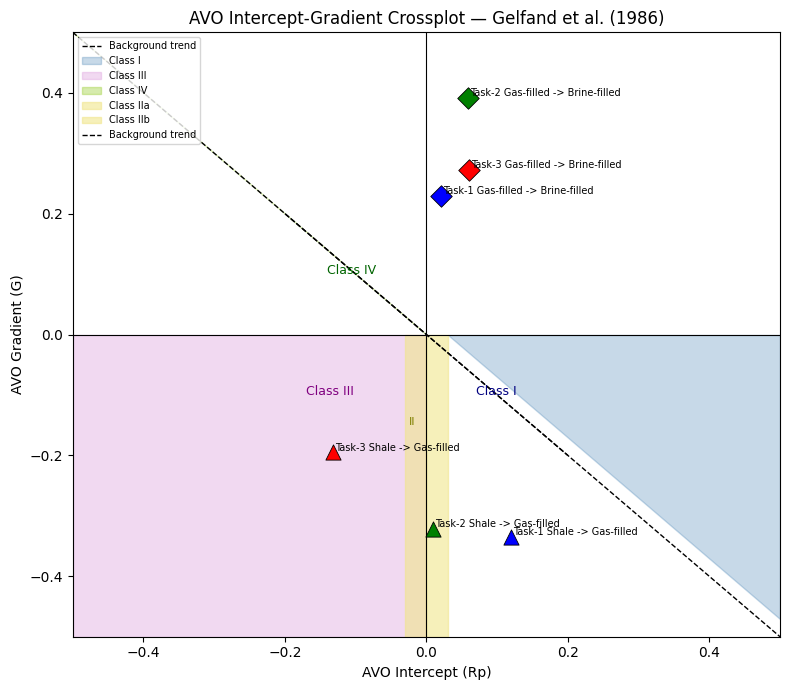

In [34]:

df = pd.read_csv("genfeld_rock_properties.csv")

records = []
for task, group in df.groupby("Task"):
    group = group.reset_index(drop=True)
    for i in range(len(group) - 1):
        a = group.iloc[i]
        b = group.iloc[i + 1]
        dVp_Vp   = (b.Vp_m_s - a.Vp_m_s)            / ((b.Vp_m_s + a.Vp_m_s) / 2)
        dVs_Vs   = (b.Vs_m_s - a.Vs_m_s)            / ((b.Vs_m_s + a.Vs_m_s) / 2)
        dRho_Rho = (b.Density_g_cc - a.Density_g_cc) / ((b.Density_g_cc + a.Density_g_cc) / 2)
        Rp = 0.5 * (dVp_Vp + dRho_Rho)
        Rs = 0.5 * (dVs_Vs + dRho_Rho)
        G  = Rp - 2 * Rs
        label = f"{a.Rock_Properties.split()[0]} -> {b.Rock_Properties.split()[0]}"
        records.append({"Task": task, "Interface": label, "Rp": Rp, "Rs": Rs, "G": G})

plot_df = pd.DataFrame(records)
print(plot_df[["Task","Interface","Rp","G"]])  # verify all 6 points

fig, ax = plt.subplots(figsize=(8, 7))

# ── AVO class background regions ─────────────────────────────────────────────
# Background trend line
x_bg = np.array([-0.5, 0.5])
ax.plot(x_bg, -x_bg, "k--", lw=1, label="Background trend")

# Class I triangle
ax.fill([ 0.03, 0.5,  0.5,  0.03], [ 0.0,  0.0, -0.47, 0.0], color="steelblue",   alpha=0.3, label="Class I")
# Class III
ax.fill([-0.5,  0.0,  0.0, -0.5],  [ 0.0,  0.0, -0.5,  -0.5], color="plum",       alpha=0.4, label="Class III")
# Class IV
ax.fill([-0.5,  0.0,  0.0, -0.5],  [ 0.5,  0.0,  0.0,   0.5], color="yellowgreen",alpha=0.4, label="Class IV")
# Class IIa
ax.fill([ 0.0,  0.03, 0.03, 0.0],  [-0.5, -0.5,  0.0,   0.0], color="khaki",      alpha=0.6, label="Class IIa")
# Class IIb
ax.fill([-0.03, 0.0,  0.0, -0.03], [-0.5, -0.5,  0.0,   0.0], color="khaki",      alpha=0.6, label="Class IIb")
# Background trend line G = -Rp
x_bg = np.array([-0.2, 0.2])
ax.plot(x_bg, -x_bg, "k--", lw=1, label="Background trend")

ax.axhline(0, color="k", lw=0.8)
ax.axvline(0, color="k", lw=0.8)

ax.text(-0.17, -0.10, "Class III", fontsize=9, color="purple")
ax.text( 0.07, -0.10, "Class I",   fontsize=9, color="navy")
ax.text(-0.14,  0.10, "Class IV",  fontsize=9, color="darkgreen")
ax.text(-0.025, -0.15, "II",       fontsize=8, color="olive")

# ── Data points ───────────────────────────────────────────────────────────────
colors  = {"Task-1": "blue", "Task-2": "green", "Task-3": "red"}
markers = {"Shale -> Gas-filled": "^", "Gas-filled -> Brine-filled": "D"}

for _, row in plot_df.iterrows():
    m = markers.get(row["Interface"], "o")
    ax.scatter(row["Rp"], row["G"], color=colors[row["Task"]], marker=m,
               s=120, edgecolors="k", linewidths=0.6, zorder=5)
    ax.text(row["Rp"] + 0.003, row["G"] + 0.003,
            f"{row['Task']} {row['Interface']}", fontsize=7, zorder=6)

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("AVO Intercept (Rp)")
ax.set_ylabel("AVO Gradient (G)")
ax.set_title("AVO Intercept-Gradient Crossplot — Gelfand et al. (1986)")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

     Task                                       Interface        Rp         G
0  Task-1           Shale caprock -> Gas-filled sandstone  0.120000 -0.334545
1  Task-1         Shale caprock -> Brine-filled sandstone  0.140833 -0.111360
2  Task-1  Gas-filled sandstone -> Brine-filled sandstone  0.020833  0.229167
3  Task-2           Shale caprock -> Gas-filled sandstone  0.009687 -0.322210
4  Task-2         Shale caprock -> Brine-filled sandstone  0.068511  0.069224
5  Task-2  Gas-filled sandstone -> Brine-filled sandstone  0.058824  0.391398
6  Task-3           Shale caprock -> Gas-filled sandstone -0.132388 -0.195059
7  Task-3         Shale caprock -> Brine-filled sandstone -0.072113  0.079579
8  Task-3  Gas-filled sandstone -> Brine-filled sandstone  0.060241  0.272345


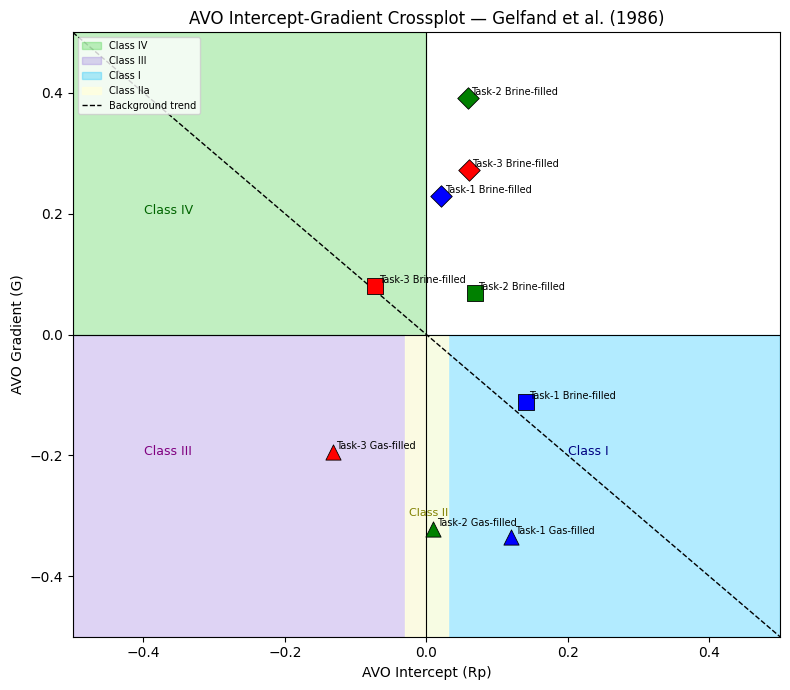

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

df = pd.read_csv("genfeld_rock_properties.csv")

records = []
for task, group in df.groupby("Task"):
    group = group.reset_index(drop=True)
    for i, j in combinations(range(len(group)), 2):
        a, b = group.iloc[i], group.iloc[j]
        Rp = 0.5 * ((b.Vp_m_s - a.Vp_m_s)            / ((b.Vp_m_s + a.Vp_m_s) / 2) +
                    (b.Density_g_cc - a.Density_g_cc) / ((b.Density_g_cc + a.Density_g_cc) / 2))
        Rs = 0.5 * ((b.Vs_m_s - a.Vs_m_s)            / ((b.Vs_m_s + a.Vs_m_s) / 2) +
                    (b.Density_g_cc - a.Density_g_cc) / ((b.Density_g_cc + a.Density_g_cc) / 2))
        G  = Rp - 2 * Rs
        records.append({"Task": task, "Interface": f"{a.Rock_Properties} -> {b.Rock_Properties}",
                        "Rp": Rp, "Rs": Rs, "G": G})

plot_df = pd.DataFrame(records)
print(plot_df[["Task","Interface","Rp","G"]].to_string())  # verify all 9 points

fig, ax = plt.subplots(figsize=(8, 7))

# AVO class background
x_bg = np.array([-0.5, 0.5])
# Class IV: entire top-left quadrant (Rp<0, G>0)
ax.fill([-0.5,  0.0,  0.0, -0.5], [ 0.0,  0.0,  0.5,  0.5], color="limegreen",   alpha=0.3, label="Class IV")
# Class III: entire bottom-left quadrant (Rp<0, G<0)
ax.fill([-0.5,  0.0,  0.0, -0.5], [ 0.0,  0.0, -0.5, -0.5], color="mediumpurple", alpha=0.3, label="Class III")
# Class I: entire bottom-right quadrant (Rp>0, G<0)
ax.fill([ 0.0,  0.5,  0.5,  0.0], [ 0.0,  0.0, -0.5, -0.5], color="deepskyblue",  alpha=0.3, label="Class I")
# Class II: thin strip around Rp=0
ax.fill([ 0.0,  0.03, 0.03, 0.0], [-0.5, -0.5,  0.0,  0.0], color="lightyellow",  alpha=0.9, label="Class IIa")
ax.fill([-0.03, 0.0,  0.0, -0.03],[-0.5, -0.5,  0.0,  0.0], color="lightyellow",  alpha=0.9)
ax.plot(x_bg, -x_bg, "k--", lw=1, label="Background trend")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(0, color="k", lw=0.8)
ax.text(-0.40, -0.20, "Class III", fontsize=9, color="purple")
ax.text( 0.20, -0.20, "Class I",   fontsize=9, color="navy")
ax.text(-0.40,  0.20, "Class IV",  fontsize=9, color="darkgreen")
ax.text(-0.025,-0.30, "Class II",  fontsize=8, color="olive")

# marker per interface type
colors  = {"Task-1": "blue", "Task-2": "green", "Task-3": "red"}
markers = {"Shale caprock -> Gas-filled sandstone":    "^",
           "Shale caprock -> Brine-filled sandstone":  "s",
           "Gas-filled sandstone -> Brine-filled sandstone": "D"}

for _, row in plot_df.iterrows():
    m = markers.get(row["Interface"], "o")
    ax.scatter(row["Rp"], row["G"], color=colors[row["Task"]], marker=m,
               s=120, edgecolors="k", linewidths=0.6, zorder=5)
    ax.text(row["Rp"] + 0.005, row["G"] + 0.005,
            f"{row['Task']} {row['Interface'].split('->')[1].strip().split()[0]}",
            fontsize=7, zorder=6)

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("AVO Intercept (Rp)")
ax.set_ylabel("AVO Gradient (G)")
ax.set_title("AVO Intercept-Gradient Crossplot — Gelfand et al. (1986)")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

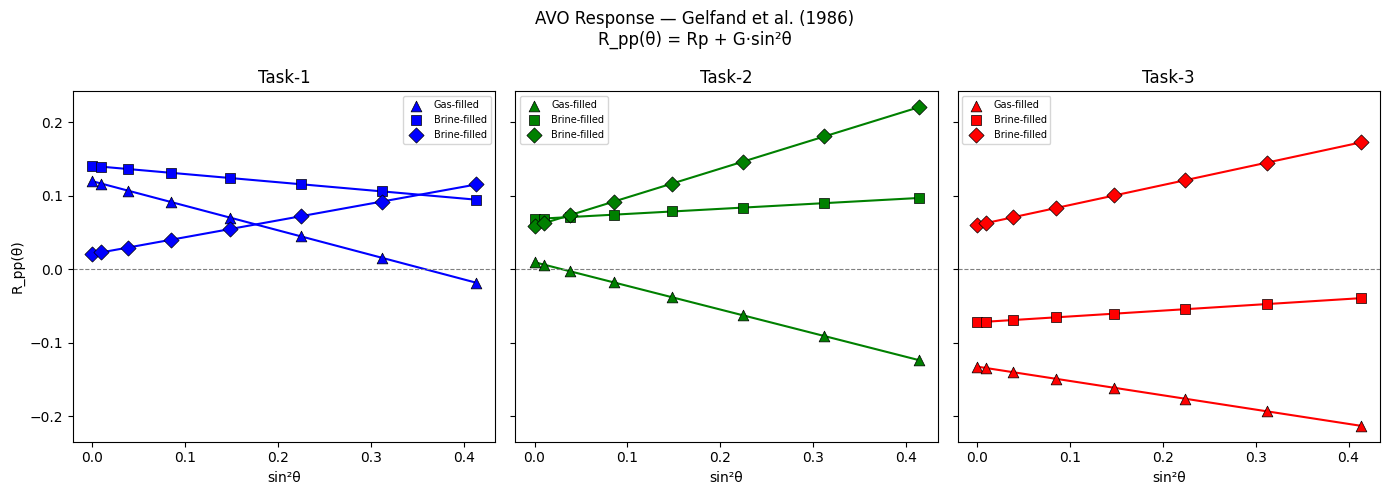

In [ ]:
def aki_richards(theta_rad, Vp1, Vs1, rho1, Vp2, Vs2, rho2):
    dVp  = Vp2  - Vp1;  Vp  = (Vp1  + Vp2)  / 2
    dVs  = Vs2  - Vs1;  Vs  = (Vs1  + Vs2)  / 2
    drho = rho2 - rho1; rho = (rho1 + rho2) / 2

    Rp   = 0.5 * (dVp/Vp + drho/rho)
    term1 = 0.5 * (dVp/Vp + drho/rho)
    term2 = 2 * (Vs/Vp)**2 * (2*dVs/Vs + drho/rho) * np.sin(theta_rad)**2
    term3 = 0.5 * (dVp/Vp) * np.tan(theta_rad)**2

    return term1 - term2 + term3

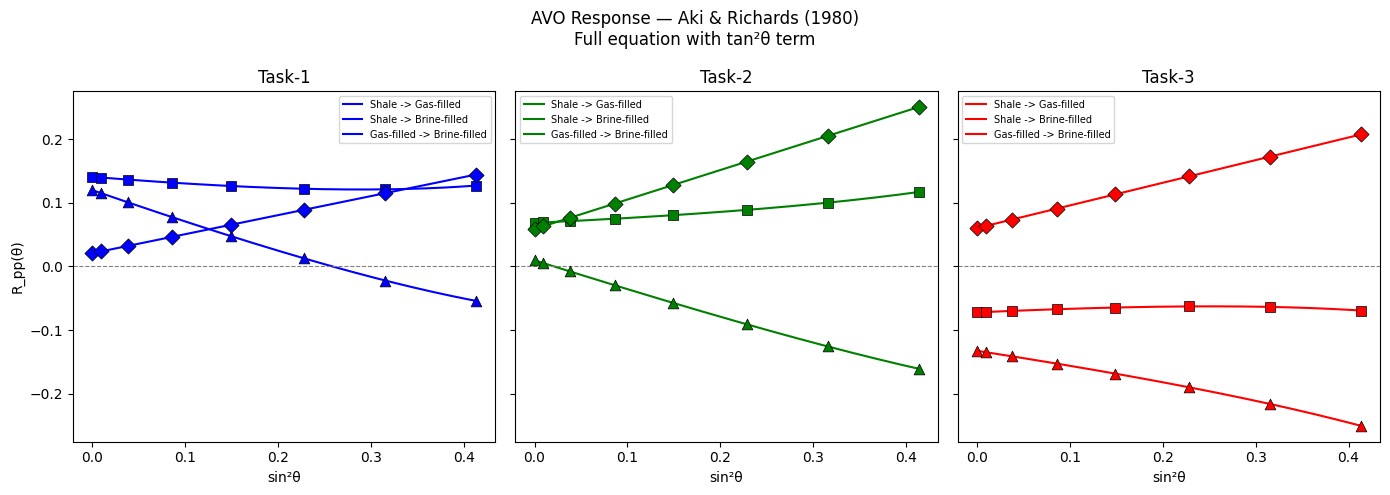

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

df = pd.read_csv("genfeld_rock_properties.csv")

def aki_richards(theta_rad, a, b):
    Vp1, Vs1, rho1 = a.Vp_m_s, a.Vs_m_s, a.Density_g_cc
    Vp2, Vs2, rho2 = b.Vp_m_s, b.Vs_m_s, b.Density_g_cc
    dVp  = Vp2 - Vp1;  Vp  = (Vp1 + Vp2) / 2
    dVs  = Vs2 - Vs1;  Vs  = (Vs1 + Vs2) / 2
    drho = rho2 - rho1; rho = (rho1 + rho2) / 2
    term1 = 0.5 * (dVp/Vp + drho/rho)
    term2 = 2 * (Vs/Vp)**2 * (2*dVs/Vs + drho/rho) * np.sin(theta_rad)**2
    term3 = 0.5 * (dVp/Vp) * np.tan(theta_rad)**2
    return term1 - term2 + term3

theta     = np.linspace(0, 40, 200)
theta_rad = np.radians(theta)
sin2      = np.sin(theta_rad)**2

colors  = {"Task-1": "blue", "Task-2": "green", "Task-3": "red"}
markers = {"Shale caprock -> Gas-filled sandstone":          "^",
           "Shale caprock -> Brine-filled sandstone":        "s",
           "Gas-filled sandstone -> Brine-filled sandstone": "D"}

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, (task, group) in zip(axes, df.groupby("Task")):
    group = group.reset_index(drop=True)
    for i, j in combinations(range(len(group)), 2):
        a, b    = group.iloc[i], group.iloc[j]
        R       = aki_richards(theta_rad, a, b)
        iface   = f"{a.Rock_Properties} -> {b.Rock_Properties}"
        label   = f"{a.Rock_Properties.split()[0]} -> {b.Rock_Properties.split()[0]}"
        m       = markers.get(iface, "o")
        ax.plot(sin2, R, color=colors[task], lw=1.5, label=label)
        idx = np.linspace(0, len(sin2)-1, 8).astype(int)
        ax.scatter(sin2[idx], R[idx], color=colors[task], marker=m,
                   s=60, edgecolors="k", linewidths=0.5, zorder=5)

    ax.axhline(0, color="gray", lw=0.8, linestyle="--")
    ax.set_title(task)
    ax.set_xlabel("sin²θ")
    ax.legend(fontsize=7)

axes[0].set_ylabel("R_pp(θ)")
fig.suptitle("AVO Response — Aki & Richards (1980)\nFull equation with tan²θ term", fontsize=12)
plt.tight_layout()
plt.show()